In [ ]:
%pip install pydeseq2

In [212]:
%pip install seaborn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 294.9/294.9 kB 9.1 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.


In [ ]:
%pip install archs4py

In [213]:
#imports
from pathlib import Path
import pandas as pd
import archs4py as a4
from pydeseq2.dds import DeseqDataSet
from pydeseq2.default_inference import DefaultInference
from pydeseq2.ds import DeseqStats
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [182]:
#load ground control and space flight from specified cohort (copy from cluster_metadata)

def get_counts_metadata(cohort_name,clist): #returns counts and metadata dataframes
    human_archs4_path = '/media/volume/H5-Files/archs4/human_gene_v2.latest.h5'
    mouse_archs4_path = '/media/volume/H5-Files/archs4/mouse_gene_v2.latest.h5'
    folder = Path.cwd().parent / "archs4metadata_cohort"
    full_name = folder / f"{cohort_name}_hits.csv"
    ch_df = pd.read_csv(full_name)
    
    #select GSM,spaceflight
    metadata = ch_df[['gsm','spaceflight']]
    metadata = metadata.groupby('gsm').filter(lambda x : len(x)<2) #drop samples that appear in ground and space
    metadata = metadata.set_index("gsm")
    metadata.index.name = None
    metadata = metadata[metadata['spaceflight'].isin(clist)]
    metadata = metadata.sort_index()
    

    #get counts
    gsms = metadata.index.tolist()
    #print(gsms)
    #gsm may be in human or mouse. but would they ever be mixed human and mouse?
    #for now just try mouse and if it fails then go human
    
    sample_counts = a4.data.samples(mouse_archs4_path,gsms)
    if sample_counts.empty:
        sample_counts = a4.data.samples(human_archs4_path,gsms)
    sample_counts = sample_counts.groupby(sample_counts.index).agg(func='sum') #collapses all the dupes
    sample_counts = sample_counts.T
    sample_counts = sample_counts.sort_index()
    
    
    
    return sample_counts,metadata
        
    
    

In [250]:
#test cohort: OSD-464
counts_df,metadata_df = get_counts_metadata('OSD-464',['Ground Control','Space Flight'])


100%|█████████████████████████████████████████| 12/12 [00:00<00:00, 291.64it/s]


In [253]:
metadata_df["spaceflight"] = pd.Categorical(
    metadata_df["spaceflight"],
    categories=["Ground Control", "Space Flight"],
    ordered=True
)

In [184]:
counts_df

,0610005C13RIK,0610006L08RIK,0610009B22RIK,0610009E02RIK,0610009L18RIK,0610010K14RIK,0610012D04RIK,0610012G03RIK,0610025J13RIK,0610030E20RIK,...,ZWILCH,ZWINT,ZXDA,ZXDB,ZXDC,ZYG11A,ZYG11B,ZYX,ZZEF1,ZZZ3
GSM1481798,7,0,17,139,9,215,0,106,2,297,...,13,394,74,27,162,0,434,1996,644,411
GSM3241163,72,0,1691,542,164,2037,13,1314,13,7529,...,378,11546,0,2501,2706,9,14034,14349,11630,14424
GSM3316477,11,0,166,435,60,341,7,248,4,692,...,31,710,18,251,247,0,1023,1698,1048,737
GSM5721810,5,0,58,46,19,348,0,159,0,475,...,8,631,4,156,173,0,494,3249,487,645
GSM5721825,8,0,164,186,36,331,0,286,2,741,...,32,992,0,399,338,0,998,1776,621,1070
GSM5721826,7,0,162,161,41,285,0,259,2,602,...,25,834,0,315,325,0,856,1976,518,942
GSM5721828,14,0,120,93,16,217,1,174,2,470,...,19,468,0,221,255,0,605,1501,522,705
GSM5907336,71,0,365,1966,178,957,9,626,3,2848,...,108,2026,0,1115,965,3,2904,7060,3951,3429
GSM6618515,21,0,257,266,48,581,1,583,5,1224,...,71,2067,0,960,509,4,2493,7500,1865,1565
GSM7187639,25,0,301,360,70,497,11,373,2,1072,...,53,1296,0,770,544,0,1659,4984,1508,1439


In [185]:
counts_df.columns[counts_df.columns.duplicated()]

Index([], dtype='str')

In [270]:
metadata_df.index.tolist()

['GSM1481798',
 'GSM3241163',
 'GSM3316477',
 'GSM5721810',
 'GSM5721825',
 'GSM5721826',
 'GSM5721828',
 'GSM5907336',
 'GSM6618515',
 'GSM7187639',
 'GSM7846529',
 'GSM7846530']

In [254]:
metadata_df

,spaceflight
GSM1481798,Space Flight
GSM3241163,Ground Control
GSM3316477,Space Flight
GSM5721810,Space Flight
GSM5721825,Ground Control
GSM5721826,Ground Control
GSM5721828,Space Flight
GSM5907336,Space Flight
GSM6618515,Ground Control
GSM7187639,Space Flight


In [256]:
#load them into the deseq format
inference = DefaultInference(n_cpus=8)
dds = DeseqDataSet(
    counts=counts_df,
    metadata=metadata_df,
    design="~spaceflight",  # compare samples based on the "condition"
    # column ("B" vs "A")
    refit_cooks=True,
    inference=inference,
)

In [ ]:
'''
Size factors: Scaling factors, for normalization
Genewise dispersions: variability in each gene's counts accross replicates
Replicate: samples with the same condition (i.e Ground)
Trend Coeff: Dispersion-mean trend (smooth curve). The coeffs are the coeffs for the parametric model
*for DE Analysis, it is not necessary to use gene lengths to estimate the scaling factors (it is even not recommended) (i.e typical normalization methods)
Deseq uses a different normalization method
MAP dispersion: applies shrinkage; uses Bayes empirical shrinkage
LFC: Log fold change

'''

In [257]:
dds.fit_size_factors() 
dds.obs["size_factors"]

Using None as control genes, passed at DeseqDataSet initialization


Fitting size factors...
... done in 0.03 seconds.



GSM1481798    0.334370
GSM3241163    7.039308
GSM3316477    0.671057
GSM5721810    0.512329
GSM5721825    0.774645
GSM5721826    0.703065
GSM5721828    0.500416
GSM5907336    2.664900
GSM6618515    1.607424
GSM7187639    1.313950
GSM7846529    1.012136
GSM7846530    1.017659
Name: size_factors, dtype: float64

In [258]:
dds.fit_genewise_dispersions()
dds.var["genewise_dispersions"]

Fitting dispersions...
... done in 4.11 seconds.



0610005C13RIK    2.219948e-01
0610006L08RIK             NaN
0610009B22RIK    1.840625e-01
0610009E02RIK    3.360300e-01
0610009L18RIK    1.842254e-01
                     ...     
ZYG11A           1.000000e-08
ZYG11B           3.008258e-02
ZYX              1.758662e-01
ZZEF1            7.753250e-02
ZZZ3             3.612794e-02
Name: genewise_dispersions, Length: 53454, dtype: float64

In [259]:
dds.fit_dispersion_trend()
dds.uns["trend_coeffs"]
dds.var["fitted_dispersions"]

Fitting dispersion trend curve...
... done in 0.89 seconds.



0610005C13RIK     0.442470
0610006L08RIK          NaN
0610009B22RIK     0.147483
0610009E02RIK     0.139543
0610009L18RIK     0.243718
                   ...    
ZYG11A           11.249258
ZYG11B            0.122770
ZYX               0.119966
ZZEF1             0.123199
ZZZ3              0.122648
Name: fitted_dispersions, Length: 53454, dtype: float64

In [260]:
dds.fit_dispersion_prior()
print(
    f"logres_prior={dds.uns['_squared_logres']}, sigma_prior={dds.uns['prior_disp_var']}"
)

logres_prior=0.8699651124015936, sigma_prior=0.6486421566644782


In [261]:
dds.fit_MAP_dispersions()
dds.var["MAP_dispersions"]
dds.var["dispersions"]

Fitting MAP dispersions...
... done in 4.51 seconds.



0610005C13RIK    0.274193
0610006L08RIK         NaN
0610009B22RIK    0.174258
0610009E02RIK    0.280342
0610009L18RIK    0.198579
                   ...   
ZYG11A           6.904811
ZYG11B           0.044264
ZYX              0.161813
ZZEF1            0.086844
ZZZ3             0.049997
Name: dispersions, Length: 53454, dtype: float64

In [262]:
dds.fit_LFC()
dds.varm["LFC"]

Fitting LFCs...
... done in 5.40 seconds.



,Intercept,spaceflight[T.Space Flight]
0610005C13RIK,2.942691,0.067898
0610006L08RIK,NaN,NaN
0610009B22RIK,5.568958,-0.430572
0610009E02RIK,5.292241,0.680666
0610009L18RIK,3.907663,0.041342
...,...,...
ZYG11A,-0.011599,-0.791404
ZYG11B,7.282652,-0.172491
ZYX,7.817854,0.487607
ZZEF1,7.007650,0.201122


In [263]:
dds.calculate_cooks()
if dds.refit_cooks:
    # Replace outlier counts
    dds.refit()

Calculating cook's distance...
... done in 0.03 seconds.

Replacing 0 outlier genes.



In [264]:
ds = DeseqStats(
    dds,
    contrast=["spaceflight", "Space Flight", "Ground Control"],
    alpha=0.05,
    cooks_filter=True,
    independent_filter=True,
)

In [265]:
ds.run_wald_test()
ds.p_values

Running Wald tests...
... done in 2.91 seconds.



0610005C13RIK    0.838763
0610006L08RIK         NaN
0610009B22RIK    0.079272
0610009E02RIK    0.027121
0610009L18RIK    0.879287
                   ...   
ZYG11A           0.646883
ZYG11B           0.160041
ZYX              0.035987
ZZEF1            0.239852
ZZZ3             0.103424
Length: 53454, dtype: float64

In [266]:
ds.summary()

Log2 fold change & Wald test p-value: spaceflight Space Flight vs Ground Control
                  baseMean  log2FoldChange     lfcSE      stat    pvalue  \
0610005C13RIK    19.607033        0.097955  0.481410  0.203476  0.838763   
0610006L08RIK     0.000000             NaN       NaN       NaN       NaN   
0610009B22RIK   215.901633       -0.621184  0.353966 -1.754926  0.079272   
0610009E02RIK   295.543732        0.981993  0.444388  2.209767  0.027121   
0610009L18RIK    50.609110        0.059643  0.392717  0.151874  0.879287   
...                    ...             ...       ...       ...       ...   
ZYG11A            0.571502       -1.141755  2.492387 -0.458097  0.646883   
ZYG11B         1338.923387       -0.248852  0.177127 -1.404935  0.160041   
ZYX            3265.823701        0.703468  0.335451  2.097078  0.035987   
ZZEF1          1227.868196        0.290158  0.246868  1.175356  0.239852   
ZZZ3           1374.218820       -0.306140  0.187992 -1.628476  0.103424   

      

In [267]:
#visualization 
df = ds.results_df

In [268]:
#pydeseq2 imports are not working, this is a direct copy paste of their function
from typing import Literal
def make_MA_plot(
    results_df: pd.DataFrame,
    padj_thresh: float = 0.05,
    log: bool = True,
    save_path: str | None = None,
    lfc_null: float = 0,
    alt_hypothesis: Literal["greaterAbs", "lessAbs", "greater", "less"] | None = None,
    **kwargs,
) -> None:
    """
    Create an log ratio (M)-average (A) plot using matplotlib.

    Useful for looking at log fold-change versus mean expression between two groups/samples/etc.
    Uses matplotlib to emulate the ``make_MA()`` function in DESeq2 in R.

    Parameters
    ----------
    results_df
        Resultant dataframe after running DeseqStats() and .summary().
    padj_thresh
        P-value threshold to subset scatterplot colors on.
    log
        Whether or not to log scale features and targets axes (``default=True``).
    save_path
        The path where to save the plot.
        If left None, the plot won't be saved (``default=None``).
    lfc_null
        The (log2) log fold change under the null hypothesis. (default: ``0``).
    alt_hypothesis
        The alternative hypothesis for computing wald p-values. (default: ``None``).
    **kwargs
        Matplotlib keyword arguments for the scatter plot.
    """
    colors = results_df["padj"].apply(lambda x: "darkred" if x < padj_thresh else "gray")

    fig, ax = plt.subplots(dpi=600)

    # Set default alpha and s parameters, if not already specified
    kwargs.setdefault("alpha", 0.5)
    kwargs.setdefault("s", 0.2)

    plt.scatter(
        x=results_df["baseMean"],
        y=results_df["log2FoldChange"],
        c=colors,
        **kwargs,
    )

    ax.set_adjustable("datalim")

    if log is True:
        plt.xscale("log")

    plt.xlabel("mean of normalized counts")
    plt.ylabel("log2 fold change")
    plt.title("MA Plot: OSD-464 Ground Control ARCHS4 Hits vs Spaceflight ARCHS4 Hits")

    plt.axhline(lfc_null, color="red", alpha=0.5, linestyle="--", zorder=3)
    if alt_hypothesis and alt_hypothesis in ["greaterAbs", "lessAbs"]:
        plt.axhline(-lfc_null, color="red", alpha=0.5, linestyle="--", zorder=3)
    plt.tight_layout()

    if save_path is not None:
        plt.savefig(save_path, bbox_inches="tight")

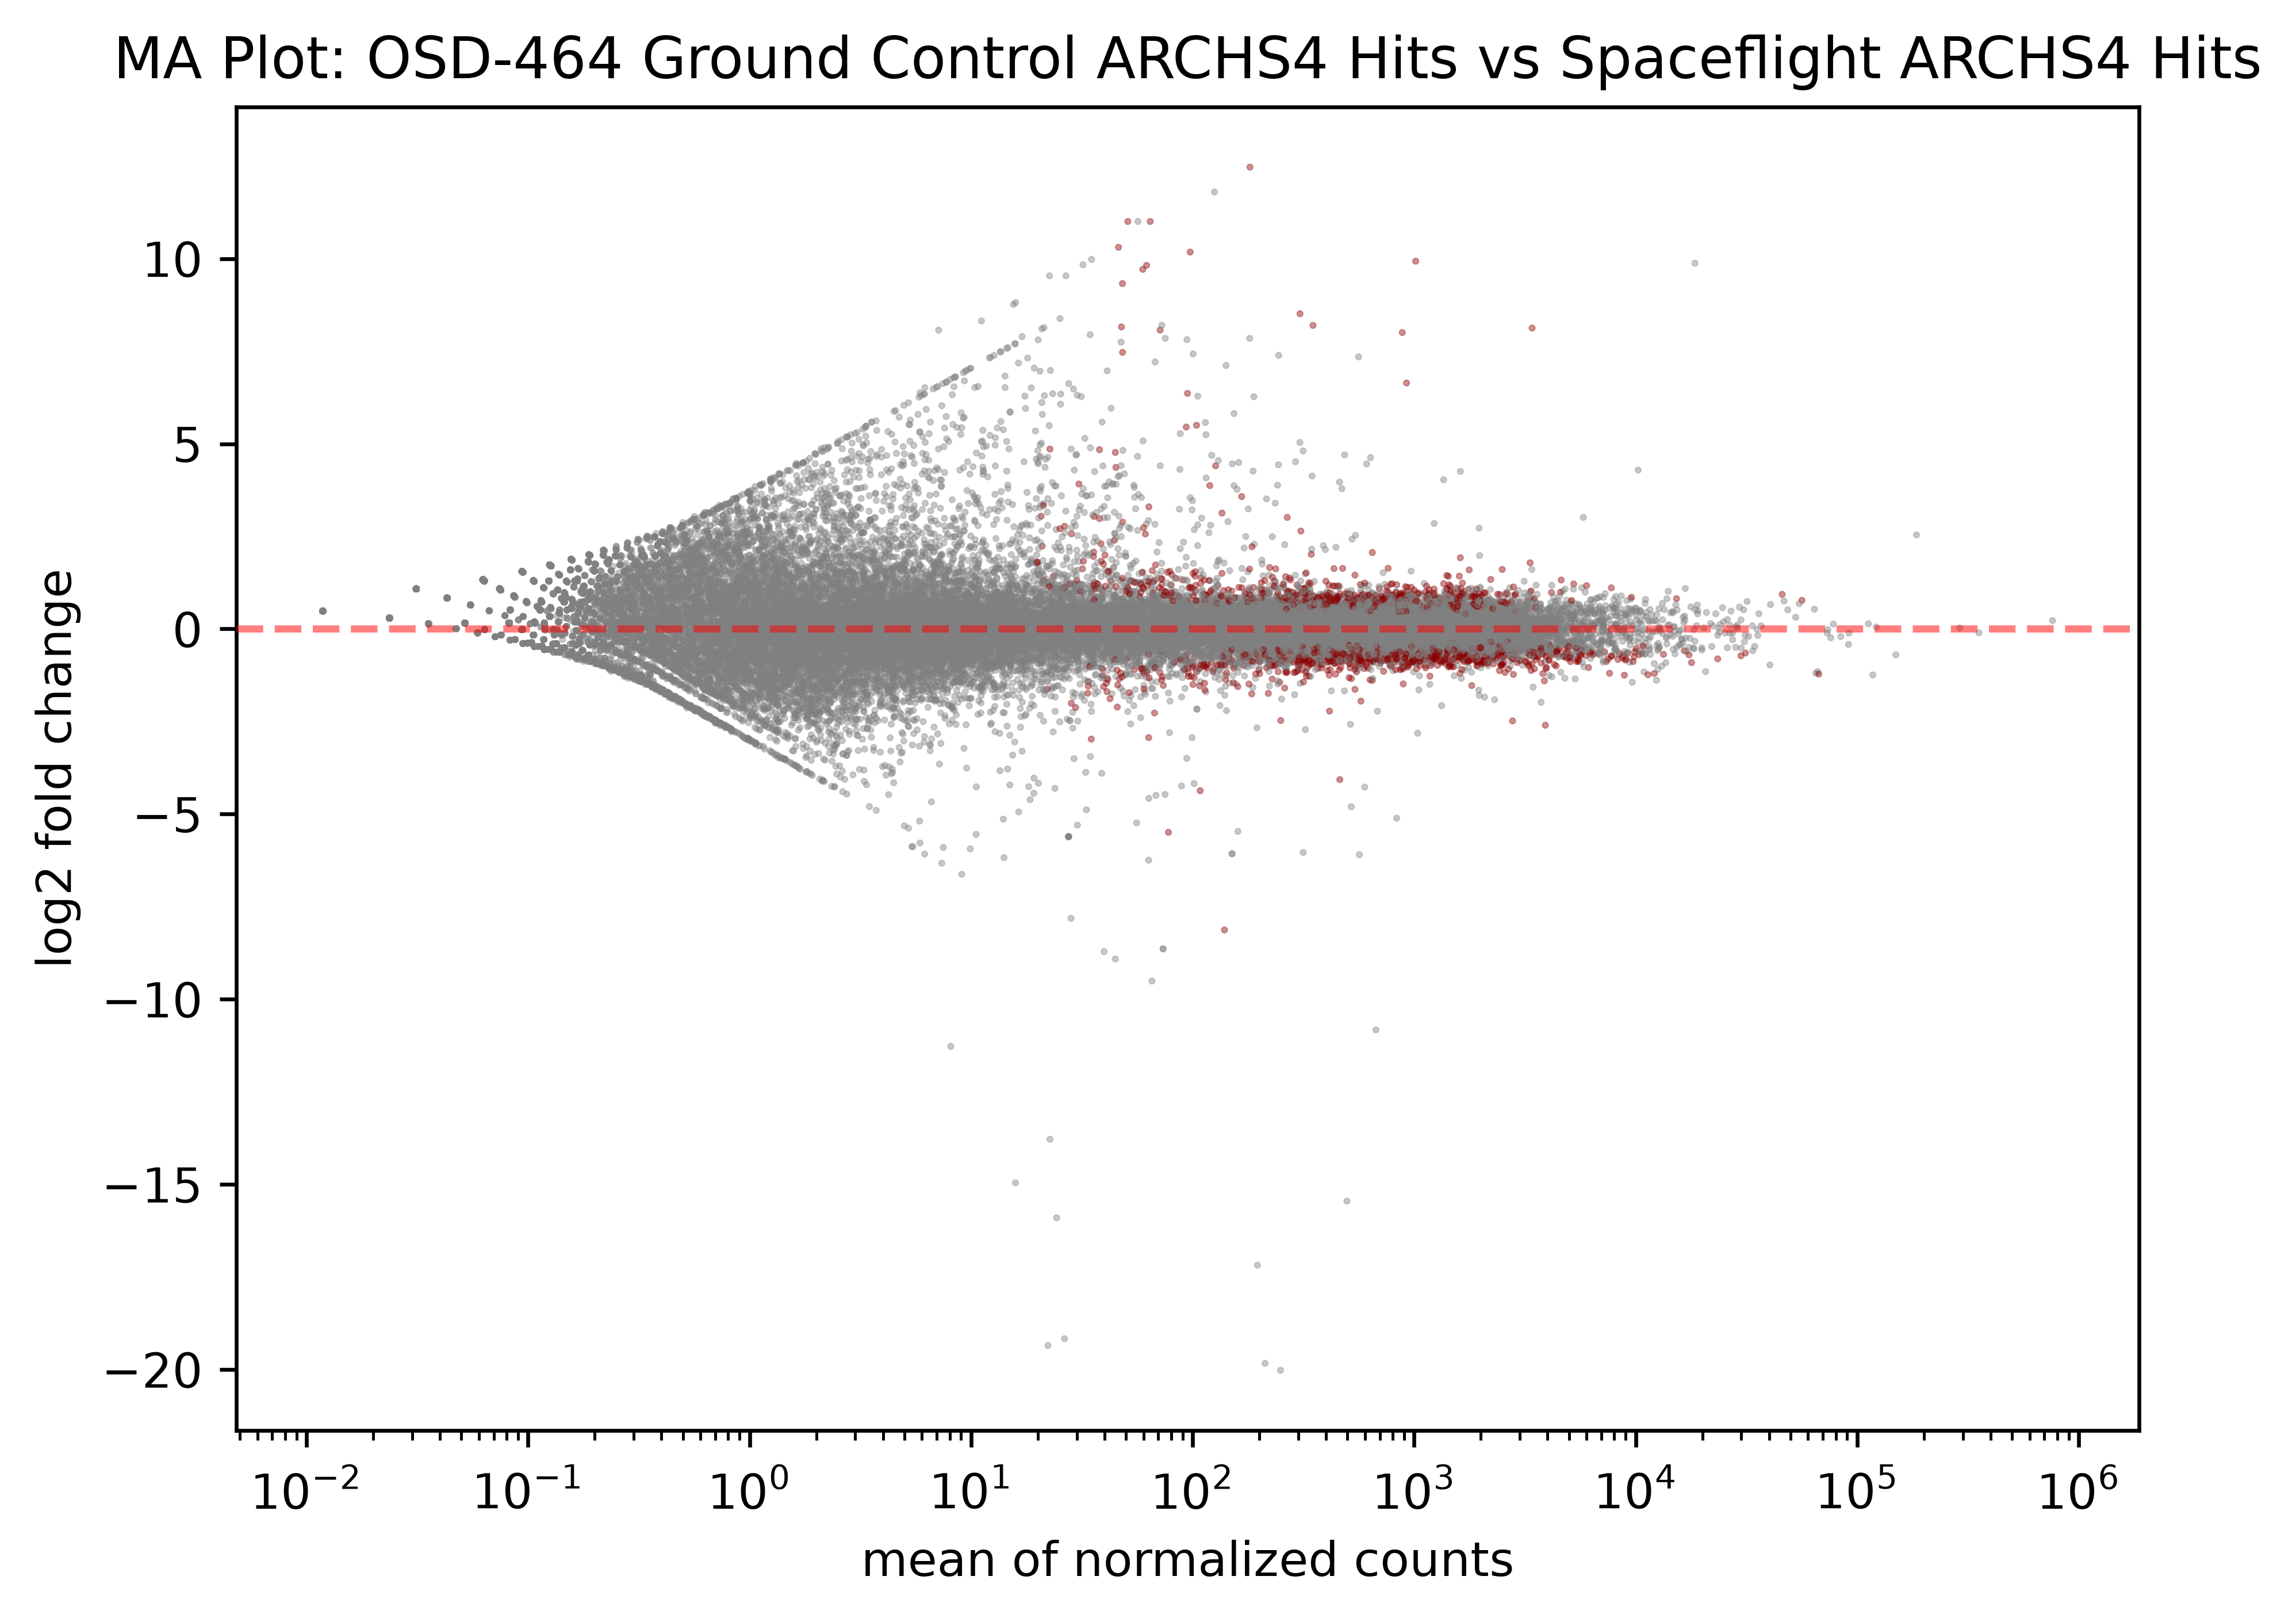

In [269]:
make_MA_plot(df)
